# Fracture Multi-Region X-Ray Classification

**End-to-end Kaggle notebook** for training, validation, testing, explainability, and submission artifact generation.

This notebook is self-contained — no external local files required.

### Sections
1. Setup
2. Config
3. Dataset Inspection
4. Dataloaders
5. Model
6. Training Loop
7. Validation Metrics
8. Test Evaluation
9. Explainability (Grad-CAM)
10. Artifact Export
11. Final Summary

In [1]:
import os

print("Top-level folders in /kaggle/input:")
for x in os.listdir("/kaggle/input"):
    print(x)

Top-level folders in /kaggle/input:
datasets


In [2]:
!find /kaggle/input -maxdepth 4 -type d | sort

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/bmadushanirodrigo
/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification


---
## 1. Setup
Install any missing packages and import all libraries.

In [3]:
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import timm
except ImportError:
    _install("timm>=1.0")

try:
    import albumentations
except ImportError:
    _install("albumentations>=1.4")

try:
    from pytorch_grad_cam import GradCAM
except ImportError:
    _install("grad-cam>=1.5")

print("All packages ready.")

All packages ready.


In [4]:
from __future__ import annotations

import copy, gc, json, math, os, random, time, warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

warnings.filterwarnings("ignore")
print(f"PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.9.0+cu126  |  CUDA available: True
GPU: Tesla T4


---
## 2. Config
Edit the variables below to customise the run.

In [5]:
# ===================== EDITABLE CONFIG ===================== #
DATASET_ROOT      = "/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

MODEL_NAME        = "resnet18"   # safer than convnext_small for now
IMAGE_SIZE        = 224
BATCH_SIZE        = 16
EPOCHS            = 10
LEARNING_RATE     = 1e-3
NUM_WORKERS       = 2
USE_MIXED_PRECISION = False
SEED              = 42

WEIGHT_DECAY      = 1e-4
WARMUP_EPOCHS     = 1
MIN_LR_RATIO      = 0.05
PATIENCE          = 3
GRAD_CLIP_NORM    = 1.0
LABEL_SMOOTHING   = 0.0
USE_CLASS_WEIGHTS = True
USE_CLAHE         = False
DROP_PATH_RATE    = 0.0
FALLBACK_TEST_SIZE = 0.15
GRAYSCALE_TO_RGB  = True

OUTPUT_DIR        = "/kaggle/working/outputs"
# =========================================================== #

print("Config set.")

Config set.


In [6]:
# ── Reproducibility & device ──
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def maybe_half_precision_dtype() -> torch.dtype:
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        return torch.bfloat16
    return torch.float16

print(f"Device: {DEVICE}")

Device: cuda


---
## 3. Dataset Inspection
Automatically detect the folder structure, class names, and whether the task is binary or multiclass.

In [7]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def _standardize_split(name: str) -> str:
    mapping = {
        "val": "val", "valid": "val", "validation": "val",
        "train": "train", "training": "train", "dev": "train",
        "test": "test", "testing": "test", "holdout": "test",
    }
    return mapping.get(name.lower().strip(), name.lower().strip())


def scan_dataset(root: str) -> pd.DataFrame:
    """Walk the dataset root and return a DataFrame with columns: path, label_name, split."""
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Dataset root not found: {root}")

    # Check for metadata CSV
    for csv_name in ["metadata.csv", "labels.csv", "train.csv", "dataset.csv"]:
        csv_path = root / csv_name
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            low = {c.lower(): c for c in df.columns}
            path_col = low.get("path") or low.get("filepath") or low.get("image_path")
            label_col = low.get("label") or low.get("class") or low.get("target")
            split_col = low.get("split")
            if path_col and label_col:
                df = df.rename(columns={path_col: "path", label_col: "label_name"})
                if split_col:
                    df = df.rename(columns={split_col: "split"})
                    df["split"] = df["split"].astype(str).map(_standardize_split)
                else:
                    df["split"] = "train"
                df["path"] = df["path"].apply(
                    lambda p: str((root / p).resolve()) if not Path(p).is_absolute() else str(Path(p).resolve())
                )
                return df[["path", "label_name", "split"]]

    # Folder-based detection
    rows = []
    split_dirs = [d for d in root.iterdir() if d.is_dir() and _standardize_split(d.name) in {"train", "val", "test"}]

    if split_dirs:
        for split_dir in split_dirs:
            split_name = _standardize_split(split_dir.name)
            for class_dir in sorted(d for d in split_dir.iterdir() if d.is_dir()):
                for img in class_dir.rglob("*"):
                    if img.is_file() and img.suffix.lower() in IMAGE_EXTS:
                        rows.append({"path": str(img.resolve()), "label_name": class_dir.name, "split": split_name})
    else:
        # Flat: root/class_x/*.png
        for class_dir in sorted(d for d in root.iterdir() if d.is_dir()):
            for img in class_dir.rglob("*"):
                if img.is_file() and img.suffix.lower() in IMAGE_EXTS:
                    rows.append({"path": str(img.resolve()), "label_name": class_dir.name, "split": "train"})

    if not rows:
        raise ValueError("No images found in dataset root.")
    return pd.DataFrame(rows)


# ── Scan ──
raw_df = scan_dataset(DATASET_ROOT)
raw_df["label_name"] = raw_df["label_name"].astype(str)
raw_df = raw_df[raw_df["path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)

CLASS_NAMES = sorted(raw_df["label_name"].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: n for n, i in CLASS_TO_IDX.items()}
raw_df["label"] = raw_df["label_name"].map(CLASS_TO_IDX).astype(int)

task_type = "binary" if NUM_CLASSES == 2 else "multiclass"
present_splits = sorted(raw_df["split"].unique().tolist())

print(f"Dataset root   : {DATASET_ROOT}")
print(f"Task type      : {task_type} ({NUM_CLASSES} classes)")
print(f"Class names    : {CLASS_NAMES}")
print(f"Detected splits: {present_splits}")
print(f"Total images   : {len(raw_df)}")
print()
print(raw_df.groupby(["split", "label_name"]).size().unstack(fill_value=0))

Dataset root   : /kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
Task type      : binary (2 classes)
Class names    : ['fractured', 'not fractured']
Detected splits: ['test', 'train', 'val']
Total images   : 10581

label_name  fractured  not fractured
split                               
test              238            268
train            4606           4640
val               337            492


In [8]:
# ── Split logic ──
# If train/val/test all present → use as-is.
# If only train (+ maybe val, no test) → create stratified test split from train.
# If train exists but no val → create stratified val split from train.
# Never leak test into training.

has_train = "train" in present_splits
has_val   = "val"   in present_splits
has_test  = "test"  in present_splits

if has_train and has_val and has_test:
    # All three present – use directly
    train_df = raw_df[raw_df["split"] == "train"].reset_index(drop=True)
    val_df   = raw_df[raw_df["split"] == "val"].reset_index(drop=True)
    test_df  = raw_df[raw_df["split"] == "test"].reset_index(drop=True)

elif has_train and has_val and not has_test:
    # No dedicated test split → carve out from train
    orig_train = raw_df[raw_df["split"] == "train"].reset_index(drop=True)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=FALLBACK_TEST_SIZE, random_state=SEED)
    tr_idx, te_idx = next(sss.split(np.arange(len(orig_train)), orig_train["label"].values))
    train_df = orig_train.iloc[tr_idx].reset_index(drop=True)
    test_df  = orig_train.iloc[te_idx].reset_index(drop=True)
    val_df   = raw_df[raw_df["split"] == "val"].reset_index(drop=True)

elif has_train and not has_val and has_test:
    # No val → split train into train+val
    orig_train = raw_df[raw_df["split"] == "train"].reset_index(drop=True)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    tr_idx, va_idx = next(sss.split(np.arange(len(orig_train)), orig_train["label"].values))
    train_df = orig_train.iloc[tr_idx].reset_index(drop=True)
    val_df   = orig_train.iloc[va_idx].reset_index(drop=True)
    test_df  = raw_df[raw_df["split"] == "test"].reset_index(drop=True)

else:
    # Only train (no val, no test) → create both
    all_train = raw_df[raw_df["split"] == "train"].reset_index(drop=True)
    # First split off test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=FALLBACK_TEST_SIZE, random_state=SEED)
    dev_idx, te_idx = next(sss1.split(np.arange(len(all_train)), all_train["label"].values))
    dev_df  = all_train.iloc[dev_idx].reset_index(drop=True)
    test_df = all_train.iloc[te_idx].reset_index(drop=True)
    # Then split dev into train+val
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    tr_idx, va_idx = next(sss2.split(np.arange(len(dev_df)), dev_df["label"].values))
    train_df = dev_df.iloc[tr_idx].reset_index(drop=True)
    val_df   = dev_df.iloc[va_idx].reset_index(drop=True)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

Train : 9246
Val   : 829
Test  : 506


---
## 4. Dataloaders
Medical-image-safe augmentations with Albumentations.

In [9]:
# ── Constants ──
IMAGE_MEAN = (0.5, 0.5, 0.5)
IMAGE_STD  = (0.25, 0.25, 0.25)


# ── Transforms ──
def get_train_transforms(image_size: int = IMAGE_SIZE, use_clahe: bool = USE_CLAHE) -> A.Compose:
    aug = [
        A.LongestMaxSize(max_size=image_size, interpolation=cv2.INTER_AREA),
        A.PadIfNeeded(min_height=image_size, min_width=image_size,
                      border_mode=cv2.BORDER_CONSTANT, value=0),
        A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.08, rotate_limit=12,
                           border_mode=cv2.BORDER_CONSTANT, value=0, p=0.6),
    ]
    if use_clahe:
        aug.append(A.CLAHE(clip_limit=(1.0, 3.0), tile_grid_size=(8, 8), p=0.3))
    aug += [
        A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.15),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
        ToTensorV2(),
    ]
    return A.Compose(aug)


def get_valid_transforms(image_size: int = IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        A.LongestMaxSize(max_size=image_size, interpolation=cv2.INTER_AREA),
        A.PadIfNeeded(min_height=image_size, min_width=image_size,
                      border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
        ToTensorV2(),
    ])


# ── Dataset ──
class FractureDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None,
                 grayscale_to_rgb: bool = True, return_paths: bool = False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.grayscale_to_rgb = grayscale_to_rgb
        self.return_paths = return_paths

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("L")
        image = np.array(image)
        if self.grayscale_to_rgb:
            image = np.stack([image, image, image], axis=-1)
        else:
            image = image[..., None]
        if self.transform:
            image = self.transform(image=image)["image"]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        label = int(row["label"])
        if self.return_paths:
            return image, label, row["path"]
        return image, label


def make_loader(df, transform, batch_size, shuffle, return_paths=False, drop_last=False):
    ds = FractureDataset(df, transform=transform,
                         grayscale_to_rgb=GRAYSCALE_TO_RGB, return_paths=return_paths)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=drop_last)


# ── Build loaders ──
train_loader = make_loader(train_df, get_train_transforms(), BATCH_SIZE, shuffle=True)
val_loader   = make_loader(val_df,   get_valid_transforms(), BATCH_SIZE, shuffle=False, return_paths=True)
test_loader  = make_loader(test_df,  get_valid_transforms(), BATCH_SIZE, shuffle=False, return_paths=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 578  |  Val batches: 52  |  Test batches: 32


---
## 5. Model
Build the classifier using `timm`.

In [10]:
class FractureClassifier(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True,
                 in_chans=3, drop_rate=0.0, drop_path_rate=0.0):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained, num_classes=num_classes,
            in_chans=in_chans, drop_rate=drop_rate, drop_path_rate=drop_path_rate,
        )

    def forward(self, x):
        return self.backbone(x)


model = FractureClassifier(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    pretrained=True,
    in_chans=3,
    drop_rate=0.0,
    drop_path_rate=DROP_PATH_RATE,
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_mb = sum(p.nelement() * p.element_size() for p in model.parameters()) / 1024**2
print(f"Model: {MODEL_NAME}  |  Params: {num_params:,}  |  Size: {model_mb:.1f} MB")

Model: resnet18  |  Params: 11,177,538  |  Size: 42.6 MB


In [11]:
# ── Loss with optional class weights ──
def compute_class_weights(labels, num_classes, device):
    counts = np.bincount(labels, minlength=num_classes)
    if np.any(counts == 0):
        return None
    w = counts.sum() / (num_classes * counts)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)

class_weights = None
if USE_CLASS_WEIGHTS:
    class_weights = compute_class_weights(train_df["label"].values, NUM_CLASSES, DEVICE)
    if class_weights is not None:
        print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

# ── Optimizer & scheduler ──
def cosine_warmup_lambda(step, warmup_steps, total_steps, min_lr_ratio=0.05):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = float(step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr_ratio + (1 - min_lr_ratio) * 0.5 * (1.0 + math.cos(math.pi * progress))

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS
scheduler = LambdaLR(optimizer, lr_lambda=lambda s: cosine_warmup_lambda(s, warmup_steps, total_steps, MIN_LR_RATIO))

scaler = GradScaler(enabled=USE_MIXED_PRECISION and DEVICE.type == "cuda")
print("Optimizer, scheduler, and scaler ready.")

Class weights: [1.004 0.996]
Optimizer, scheduler, and scaler ready.


---
## 6. Training Loop
Train with mixed-precision, gradient clipping, cosine-warmup schedule, and early stopping on **Macro F1**.

In [12]:
# ── Early stopping ──
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.bad_epochs, self.should_stop = None, 0, False

    def step(self, value):
        if self.best is None:
            self.best = value
            return False
        if value - self.best > self.min_delta:
            self.best = value
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
            if self.bad_epochs >= self.patience:
                self.should_stop = True
        return self.should_stop


# ── Helpers ──
def safe_auc(y_true, y_prob):
    unique = np.unique(y_true)
    if unique.shape[0] < 2:
        return None
    try:
        if y_prob.shape[1] == 2:
            return float(roc_auc_score(y_true, y_prob[:, 1]))
        classes = np.arange(y_prob.shape[1])
        y_bin = label_binarize(y_true, classes=classes)
        return float(roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"))
    except Exception:
        return None


def compute_metrics(y_true, y_pred, y_prob, class_names):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(class_names)), zero_division=0)
    per_class_acc = []
    for i in range(len(class_names)):
        rs = cm[i].sum()
        per_class_acc.append(float(cm[i, i] / rs) if rs > 0 else 0.0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_macro": float(np.mean(prec)),
        "recall_macro": float(np.mean(rec)),
        "auc_ovr_macro": safe_auc(y_true, y_prob),
        "confusion_matrix": cm.tolist(),
        "per_class": {
            cn: {"precision": float(prec[i]), "recall": float(rec[i]),
                 "f1": float(f1[i]), "support": int(sup[i]),
                 "accuracy": float(per_class_acc[i])}
            for i, cn in enumerate(class_names)
        },
    }


def move_batch(batch, device):
    if len(batch) == 3:
        imgs, labs, paths = batch
        return imgs.to(device, non_blocking=True), labs.to(device, non_blocking=True), paths
    imgs, labs = batch
    return imgs.to(device, non_blocking=True), labs.to(device, non_blocking=True), None


print("Training utilities ready.")

Training utilities ready.


In [13]:
# ── Training ──
use_amp = USE_MIXED_PRECISION and DEVICE.type == "cuda"
amp_dtype = maybe_half_precision_dtype()
early_stopper = EarlyStopping(patience=PATIENCE)

best_metric = -float("inf")
best_epoch = 0
checkpoint_path = os.path.join(OUTPUT_DIR, "best_model.pth")
history = []

train_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    # ── Train phase ──
    model.train()
    running_loss, total, all_t, all_p = 0.0, 0, [], []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=False)
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(pbar, 1):
        imgs, labs, _ = move_batch(batch, DEVICE)
        bs = imgs.shape[0]
        with autocast(enabled=use_amp, dtype=amp_dtype):
            logits = model(imgs)
            loss = criterion(logits, labs)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

        running_loss += loss.item() * bs
        total += bs
        preds = torch.argmax(logits.detach(), dim=1)
        all_t.append(labs.cpu().numpy())
        all_p.append(preds.cpu().numpy())
        pbar.set_postfix(loss=f"{running_loss/total:.4f}")

    train_loss = running_loss / max(total, 1)
    yt = np.concatenate(all_t)
    yp = np.concatenate(all_p)
    train_acc = float((yt == yp).mean())

    # ── Validation phase ──
    model.eval()
    vl_loss, vl_total = 0.0, 0
    vl_targets, vl_probs, vl_preds, vl_paths = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False):
            imgs, labs, paths = move_batch(batch, DEVICE)
            bs = imgs.shape[0]
            with autocast(enabled=use_amp, dtype=amp_dtype):
                logits = model(imgs)
                loss = criterion(logits, labs)
            vl_loss += loss.item() * bs
            vl_total += bs
            probs = torch.softmax(logits, dim=1)
            vl_targets.append(labs.cpu().numpy())
            vl_probs.append(probs.cpu().numpy())
            vl_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
            if paths is not None:
                vl_paths.extend(list(paths))

    val_loss = vl_loss / max(vl_total, 1)
    y_true_v = np.concatenate(vl_targets)
    y_prob_v = np.concatenate(vl_probs)
    y_pred_v = np.concatenate(vl_preds)
    val_met = compute_metrics(y_true_v, y_pred_v, y_prob_v, CLASS_NAMES)
    val_f1 = val_met["macro_f1"]
    val_acc = val_met["accuracy"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_accuracy": train_acc, "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "overfitting_gap": val_loss - train_loss,
        "lr": optimizer.param_groups[0]["lr"],
    })

    improved = ""
    if val_f1 > best_metric:
        best_metric = val_f1
        best_epoch = epoch
        torch.save({
            "state_dict": model.state_dict(),
            "class_names": CLASS_NAMES,
            "model_name": MODEL_NAME,
            "image_size": IMAGE_SIZE,
            "best_metric": best_metric,
            "best_epoch": best_epoch,
        }, checkpoint_path)
        improved = " ★"

    print(f"Epoch {epoch:02d}  TrLoss={train_loss:.4f}  VaLoss={val_loss:.4f}  "
          f"TrAcc={train_acc:.4f}  VaAcc={val_acc:.4f}  VaF1={val_f1:.4f}{improved}")

    if early_stopper.step(val_f1):
        print(f"Early stopping at epoch {epoch}.")
        break

train_time = time.perf_counter() - train_start
print(f"\nTraining complete in {train_time:.0f}s.  Best Val Macro F1 = {best_metric:.4f} (epoch {best_epoch})")

Epoch 1/10 [train]:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/52 [00:00<?, ?it/s]

Epoch 01  TrLoss=0.3784  VaLoss=0.1238  TrAcc=0.8092  VaAcc=0.9505  VaF1=0.9487 ★


Epoch 2/10 [train]:   0%|          | 0/578 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a297a7479c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a297a7479c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch 09  TrLoss=0.0054  VaLoss=0.0183  TrAcc=0.9983  VaAcc=0.9928  VaF1=0.9925 ★


Epoch 10/10 [train]:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/52 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a297a7479c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a297a7479c0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 10  TrLoss=0.0048  VaLoss=0.0184  TrAcc=0.9986  VaAcc=0.9964  VaF1=0.9962 ★

Training complete in 529s.  Best Val Macro F1 = 0.9962 (epoch 10)


---
## 7. Validation Metrics
Load the best checkpoint and compute full validation metrics.

In [14]:
# ── Reload best checkpoint ──
ckpt = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()

# ── Full validation eval ──
vl_targets, vl_probs, vl_preds, vl_paths = [], [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Val eval"):
        imgs, labs, paths = move_batch(batch, DEVICE)
        with autocast(enabled=use_amp, dtype=amp_dtype):
            logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        vl_targets.append(labs.cpu().numpy())
        vl_probs.append(probs.cpu().numpy())
        vl_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        if paths is not None:
            vl_paths.extend(list(paths))

y_true_val = np.concatenate(vl_targets)
y_prob_val = np.concatenate(vl_probs)
y_pred_val = np.concatenate(vl_preds)
val_metrics = compute_metrics(y_true_val, y_pred_val, y_prob_val, CLASS_NAMES)

print("\n=== Validation Results (best checkpoint) ===")
print(f"  Accuracy   : {val_metrics['accuracy']:.4f}")
print(f"  Precision  : {val_metrics['precision_macro']:.4f}")
print(f"  Recall     : {val_metrics['recall_macro']:.4f}")
print(f"  Macro F1   : {val_metrics['macro_f1']:.4f}")
print(f"  ROC-AUC    : {val_metrics['auc_ovr_macro']}")
print()
print(classification_report(y_true_val, y_pred_val, target_names=CLASS_NAMES, zero_division=0))

Val eval:   0%|          | 0/52 [00:00<?, ?it/s]


=== Validation Results (best checkpoint) ===
  Accuracy   : 0.9964
  Precision  : 0.9970
  Recall     : 0.9955
  Macro F1   : 0.9962
  ROC-AUC    : 0.9998311259076983

               precision    recall  f1-score   support

    fractured       1.00      0.99      1.00       337
not fractured       0.99      1.00      1.00       492

     accuracy                           1.00       829
    macro avg       1.00      1.00      1.00       829
 weighted avg       1.00      1.00      1.00       829



---
## 8. Test Evaluation
Run inference on the held-out test set.

In [15]:
model.eval()
te_targets, te_probs, te_preds, te_paths = [], [], [], []
te_time_start = time.perf_counter()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test eval"):
        imgs, labs, paths = move_batch(batch, DEVICE)
        with autocast(enabled=use_amp, dtype=amp_dtype):
            logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        te_targets.append(labs.cpu().numpy())
        te_probs.append(probs.cpu().numpy())
        te_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        if paths is not None:
            te_paths.extend(list(paths))

te_time = time.perf_counter() - te_time_start
y_true_te = np.concatenate(te_targets)
y_prob_te = np.concatenate(te_probs)
y_pred_te = np.concatenate(te_preds)
test_metrics = compute_metrics(y_true_te, y_pred_te, y_prob_te, CLASS_NAMES)
test_metrics["inference_time_sec"] = te_time
test_metrics["inference_time_ms_per_image"] = 1000.0 * te_time / max(len(y_true_te), 1)

print("\n=== Test Results ===")
print(f"  Accuracy   : {test_metrics['accuracy']:.4f}")
print(f"  Precision  : {test_metrics['precision_macro']:.4f}")
print(f"  Recall     : {test_metrics['recall_macro']:.4f}")
print(f"  Macro F1   : {test_metrics['macro_f1']:.4f}")
print(f"  ROC-AUC    : {test_metrics['auc_ovr_macro']}")
print(f"  Inference  : {test_metrics['inference_time_ms_per_image']:.1f} ms/image")
print()
print(classification_report(y_true_te, y_pred_te, target_names=CLASS_NAMES, zero_division=0))

Test eval:   0%|          | 0/32 [00:00<?, ?it/s]


=== Test Results ===
  Accuracy   : 0.9921
  Precision  : 0.9926
  Recall     : 0.9916
  Macro F1   : 0.9921
  ROC-AUC    : 1.0
  Inference  : 13.9 ms/image

               precision    recall  f1-score   support

    fractured       1.00      0.98      0.99       238
not fractured       0.99      1.00      0.99       268

     accuracy                           0.99       506
    macro avg       0.99      0.99      0.99       506
 weighted avg       0.99      0.99      0.99       506



---
## 9. Explainability (Grad-CAM)
Visualise Grad-CAM heatmaps on a few test images.

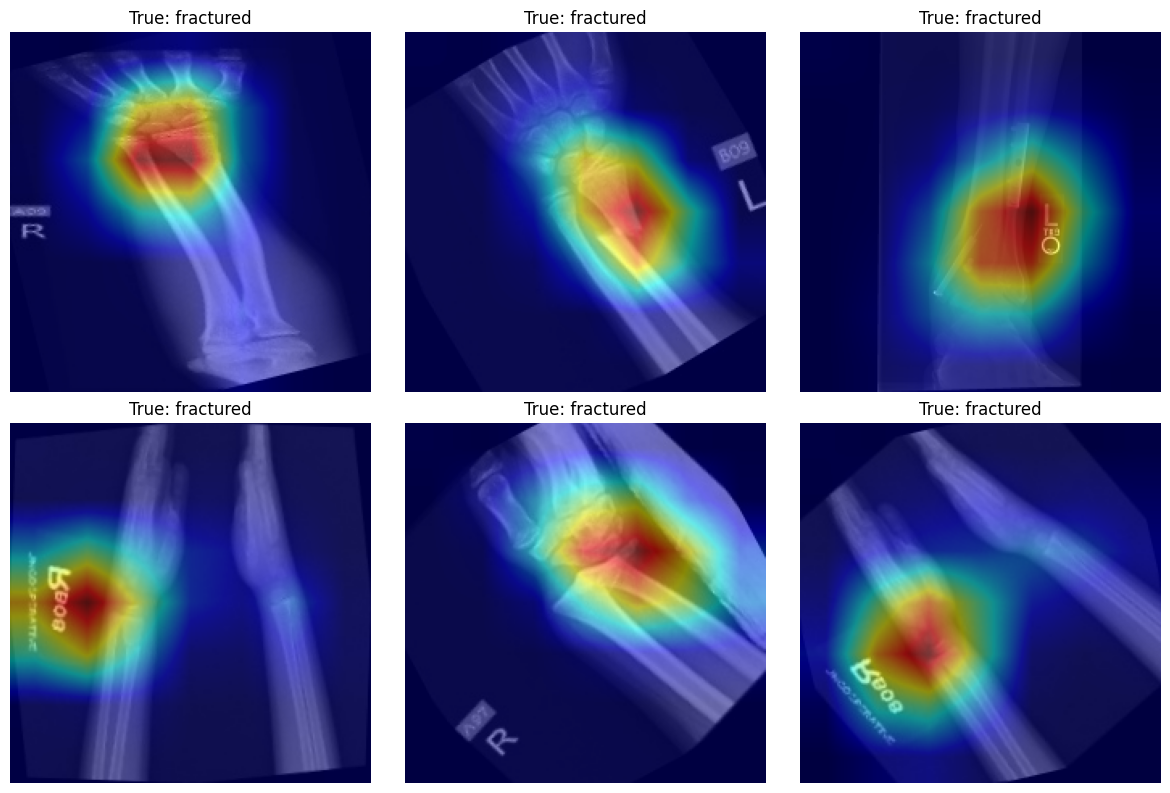

Saved: /kaggle/working/outputs/gradcam_examples.png


In [16]:
def find_target_layer(model):
    named = dict(model.named_modules())
    candidates = [
        "backbone.stages.3.blocks.2.norm",
        "backbone.stages.3.blocks.1.norm",
        "backbone.stages.3",
        "backbone.norm",
        "backbone.head.global_pool",
        "backbone.layer4",
        "backbone.features",
    ]
    for key in candidates:
        if key in named:
            return named[key]
    # Fallback: last module with weight
    fallback = None
    for _, m in named.items():
        if hasattr(m, "weight"):
            fallback = m
    if fallback is None:
        raise ValueError("Cannot find Grad-CAM target layer.")
    return fallback


try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    # Grab a small batch from test set
    gc_loader = make_loader(test_df.head(6), get_valid_transforms(), batch_size=6, shuffle=False)
    gc_batch = next(iter(gc_loader))
    gc_imgs, gc_labs = gc_batch[0], gc_batch[1]
    target_layer = find_target_layer(model)

    cam = GradCAM(model=model, target_layers=[target_layer])
    cam_maps = cam(input_tensor=gc_imgs.to(DEVICE))

    n = min(6, gc_imgs.shape[0])
    cols = min(n, 3)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(rows * cols):
        ax = axes[i]
        ax.axis("off")
        if i >= n:
            continue
        img_np = gc_imgs[i].permute(1, 2, 0).numpy()
        img_np = (img_np - img_np.min()) / max(img_np.max() - img_np.min(), 1e-8)
        overlay = show_cam_on_image(img_np, cam_maps[i], use_rgb=True)
        ax.imshow(overlay)
        label_name = IDX_TO_CLASS.get(int(gc_labs[i]), str(int(gc_labs[i])))
        ax.set_title(f"True: {label_name}")

    plt.tight_layout()
    gradcam_path = os.path.join(OUTPUT_DIR, "gradcam_examples.png")
    plt.savefig(gradcam_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {gradcam_path}")

except Exception as e:
    print(f"Grad-CAM skipped: {e}")

---
## 10. Artifact Export
Save all required CSVs, plots, and checkpoint.

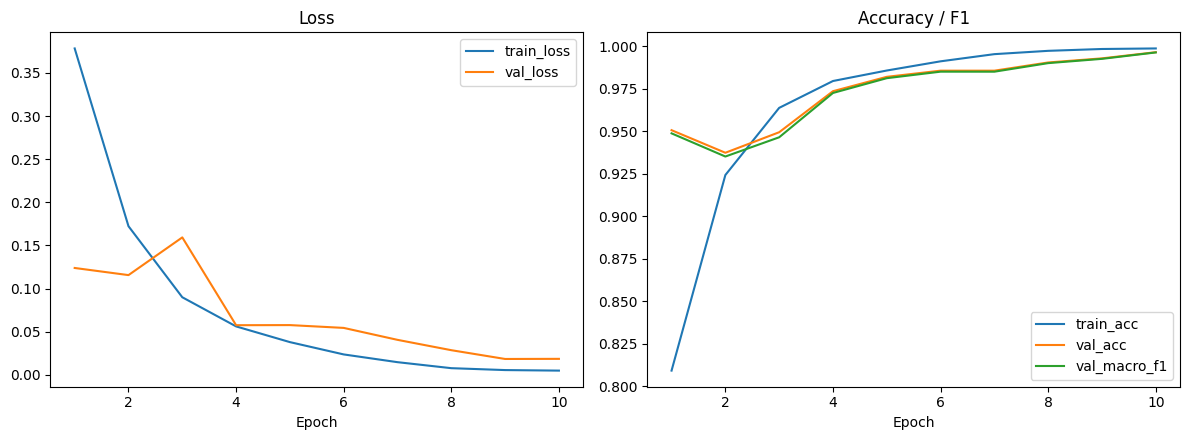

Saved: /kaggle/working/outputs/training_curves.png


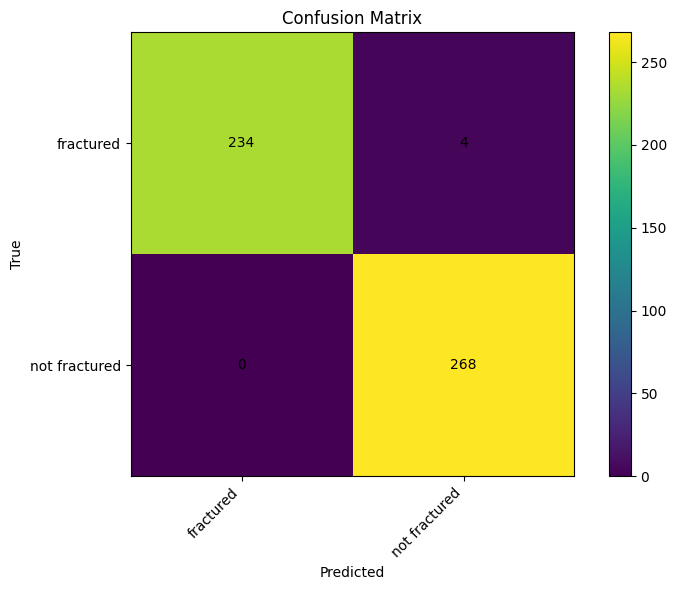

Saved: /kaggle/working/outputs/confusion_matrix.png


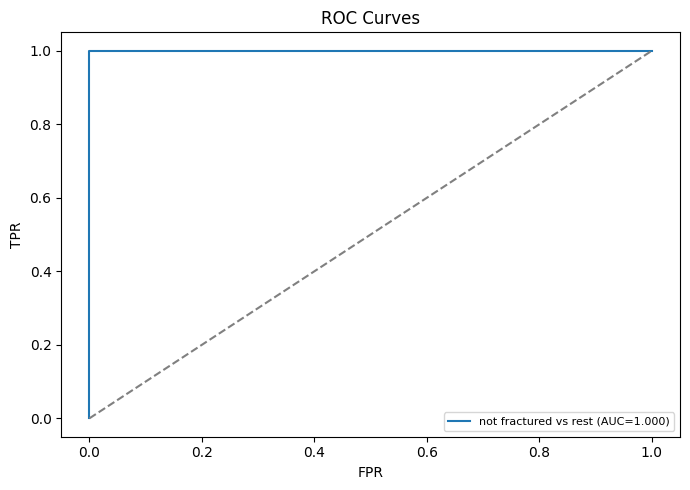

Saved: /kaggle/working/outputs/roc_curve.png


In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Training curves ──
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(hist_df["epoch"], hist_df["train_accuracy"], label="train_acc")
axes[1].plot(hist_df["epoch"], hist_df["val_accuracy"], label="val_acc")
axes[1].plot(hist_df["epoch"], hist_df["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("Accuracy / F1"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
tc_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(tc_path, dpi=220, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved: {tc_path}")

# ── 2. Confusion matrix ──
cm = np.array(test_metrics["confusion_matrix"], dtype=float)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
plt.colorbar(im, ax=ax)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(int(cm[i, j])), ha="center", va="center")
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved: {cm_path}")

# ── 3. ROC curves ──
fig, ax = plt.subplots(figsize=(7, 5))
if NUM_CLASSES == 2 and y_prob_te.shape[1] == 2:
    fpr, tpr, _ = roc_curve(y_true_te, y_prob_te[:, 1])
    auc_val = roc_auc_score(y_true_te, y_prob_te[:, 1])
    ax.plot(fpr, tpr, label=f"{CLASS_NAMES[1]} vs rest (AUC={auc_val:.3f})")
else:
    y_bin = label_binarize(y_true_te, classes=np.arange(NUM_CLASSES))
    for idx, cn in enumerate(CLASS_NAMES):
        if idx >= y_prob_te.shape[1] or y_bin[:, idx].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, idx], y_prob_te[:, idx])
        auc_val = roc_auc_score(y_bin[:, idx], y_prob_te[:, idx])
        ax.plot(fpr, tpr, label=f"{cn} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC Curves")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
roc_path = os.path.join(OUTPUT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=220, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"Saved: {roc_path}")

In [18]:
# ── 4. per_class_metrics.csv ──
pc_rows = []
for cn, vals in test_metrics["per_class"].items():
    pc_rows.append({"class_name": cn, **vals})
per_class_df = pd.DataFrame(pc_rows)
pc_path = os.path.join(OUTPUT_DIR, "per_class_metrics.csv")
per_class_df.to_csv(pc_path, index=False)
print(f"Saved: {pc_path}")
per_class_df

Saved: /kaggle/working/outputs/per_class_metrics.csv


,class_name,precision,recall,f1,support,accuracy
0,fractured,1.000000,0.983193,0.991525,238,0.983193
1,not fractured,0.985294,1.000000,0.992593,268,1.000000


In [19]:
# ── 5. final_results.csv ──
def _row(name, overall, class_vals, interp):
    r = {"metric_name": name, "overall_value": overall}
    for cn, v in zip(CLASS_NAMES, class_vals):
        r[cn] = v
    r["interpretation"] = interp
    return r

pc = test_metrics["per_class"]
fr_rows = [
    _row("Accuracy", test_metrics["accuracy"], [None]*NUM_CLASSES, "Overall correctness"),
    _row("Precision", test_metrics["precision_macro"],
         [pc[c]["precision"] for c in CLASS_NAMES], "Positive prediction reliability"),
    _row("Recall", test_metrics["recall_macro"],
         [pc[c]["recall"] for c in CLASS_NAMES], "Detection rate per class"),
    _row("F1-Score", test_metrics["macro_f1"],
         [pc[c]["f1"] for c in CLASS_NAMES], "Balanced performance across classes"),
    _row("Per-Class Accuracy", np.mean([pc[c]["accuracy"] for c in CLASS_NAMES]),
         [pc[c]["accuracy"] for c in CLASS_NAMES], "Classwise hit rate"),
    _row("AUC-ROC", test_metrics["auc_ovr_macro"], [None]*NUM_CLASSES, "Ranking quality"),
    _row("Training Time (sec)", round(train_time, 1), [None]*NUM_CLASSES, "End-to-end training time"),
    _row("Inference Time (ms/image)", round(test_metrics["inference_time_ms_per_image"], 2),
         [None]*NUM_CLASSES, "Average test-time latency"),
    _row("Model Size (MB)", round(model_mb, 1), [None]*NUM_CLASSES, "Checkpoint size"),
]
fr_df = pd.DataFrame(fr_rows)
fr_path = os.path.join(OUTPUT_DIR, "final_results.csv")
fr_df.to_csv(fr_path, index=False)
print(f"Saved: {fr_path}")
fr_df

Saved: /kaggle/working/outputs/final_results.csv


,metric_name,overall_value,fractured,not fractured,interpretation
0,Accuracy,0.992095,NaN,NaN,Overall correctness
1,Precision,0.992647,1.000000,0.985294,Positive prediction reliability
2,Recall,0.991597,0.983193,1.000000,Detection rate per class
3,F1-Score,0.992059,0.991525,0.992593,Balanced performance across classes
4,Per-Class Accuracy,0.991597,0.983193,1.000000,Classwise hit rate
5,AUC-ROC,1.000000,NaN,NaN,Ranking quality
6,Training Time (sec),528.800000,NaN,NaN,End-to-end training time
7,Inference Time (ms/image),13.890000,NaN,NaN,Average test-time latency
8,Model Size (MB),42.600000,NaN,NaN,Checkpoint size


In [20]:
# ── 6. model_performance_analysis.csv ──
hist_df.to_csv(os.path.join(OUTPUT_DIR, "model_performance_analysis.csv"), index=False)

# Append generalization summary
mpa_path = os.path.join(OUTPUT_DIR, "model_performance_analysis.csv")
max_gap = hist_df["overfitting_gap"].max() if not hist_df.empty else 0.0
final_train_acc = hist_df["train_accuracy"].iloc[-1] if not hist_df.empty else 0.0
train_test_delta = final_train_acc - test_metrics["accuracy"]
with open(mpa_path, "a", encoding="utf-8") as f:
    f.write("\n")
    f.write("GENERALIZATION METRICS:\n")
    f.write(f"Max Overfitting Gap,{max_gap:.6f}\n")
    f.write(f"Best Val Accuracy,{val_metrics['accuracy']:.6f} (epoch {best_epoch})\n")
    f.write(f"Test Accuracy,{test_metrics['accuracy']:.6f}\n")
    f.write(f"Train/Test Accuracy Delta,{train_test_delta:.6f}\n")
print(f"Saved: {mpa_path}")

# ── 7. Test predictions CSV ──
pred_df = pd.DataFrame({
    "path": te_paths if te_paths else [None]*len(y_true_te),
    "y_true": y_true_te,
    "y_pred": y_pred_te,
    "y_true_name": [IDX_TO_CLASS[int(y)] for y in y_true_te],
    "y_pred_name": [IDX_TO_CLASS[int(y)] for y in y_pred_te],
})
for idx, cn in enumerate(CLASS_NAMES):
    pred_df[f"prob_{cn}"] = y_prob_te[:, idx]
pred_csv_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
pred_df.to_csv(pred_csv_path, index=False)
print(f"Saved: {pred_csv_path}")
print(f"\nAll artifacts written to {OUTPUT_DIR}")

Saved: /kaggle/working/outputs/model_performance_analysis.csv
Saved: /kaggle/working/outputs/test_predictions.csv

All artifacts written to /kaggle/working/outputs


---
## 11. Final Summary

In [21]:
print("=" * 60)
print("           FRACTURE CLASSIFICATION — RUN SUMMARY")
print("=" * 60)
print(f"  Dataset root       : {DATASET_ROOT}")
print(f"  Task type          : {task_type}")
print(f"  Detected classes   : {CLASS_NAMES}")
print(f"  Num classes        : {NUM_CLASSES}")
print(f"  Train / Val / Test : {len(train_df)} / {len(val_df)} / {len(test_df)}")
print(f"  Model              : {MODEL_NAME}")
print(f"  Parameters         : {num_params:,}")
print(f"  Image size         : {IMAGE_SIZE}")
print(f"  Epochs trained     : {len(history)}")
print(f"  Best epoch         : {best_epoch}")
print(f"  Training time      : {train_time:.0f}s")
print()
print("  --- Validation (best ckpt) ---")
print(f"  Accuracy           : {val_metrics['accuracy']:.4f}")
print(f"  Macro F1           : {val_metrics['macro_f1']:.4f}")
print(f"  ROC-AUC            : {val_metrics['auc_ovr_macro']}")
print()
print("  --- Test ---")
print(f"  Accuracy           : {test_metrics['accuracy']:.4f}")
print(f"  Precision (macro)  : {test_metrics['precision_macro']:.4f}")
print(f"  Recall (macro)     : {test_metrics['recall_macro']:.4f}")
print(f"  Macro F1           : {test_metrics['macro_f1']:.4f}")
print(f"  ROC-AUC            : {test_metrics['auc_ovr_macro']}")
print(f"  Inference          : {test_metrics['inference_time_ms_per_image']:.1f} ms/image")
print()
print("  --- Saved Outputs ---")
for f in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(full) / 1024
    print(f"    {f:40s} ({size_kb:.1f} KB)")
print("=" * 60)
print("Done.")

           FRACTURE CLASSIFICATION — RUN SUMMARY
  Dataset root       : /kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
  Task type          : binary
  Detected classes   : ['fractured', 'not fractured']
  Num classes        : 2
  Train / Val / Test : 9246 / 829 / 506
  Model              : resnet18
  Parameters         : 11,177,538
  Image size         : 224
  Epochs trained     : 10
  Best epoch         : 10
  Training time      : 529s

  --- Validation (best ckpt) ---
  Accuracy           : 0.9964
  Macro F1           : 0.9962
  ROC-AUC            : 0.9998311259076983

  --- Test ---
  Accuracy           : 0.9921
  Precision (macro)  : 0.9926
  Recall (macro)     : 0.9916
  Macro F1           : 0.9921
  ROC-AUC            : 1.0
  Inference          : 13.9 ms/image

  --- Saved Outputs ---
    best_model.pth                           (43743.1 KB)
    confusion_matrix.png                 